In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix
)

from xgboost import XGBRegressor, XGBClassifier
from xgboost.callback import EarlyStopping

In [66]:
pwd

'/mnt/Windows/Users/ashto/Disk/Projects/BoxOfficeAI/backend/notebooks'

In [67]:
df = pd.read_csv('../../data/movies.csv', low_memory=False)
credits = pd.read_csv('../../data/credits.csv')

print("Movies:", df.shape)
print("Credits:", credits.shape)

Movies: (45466, 24)
Credits: (45476, 3)


In [68]:
df["id"] = pd.to_numeric(df["id"], errors="coerce")
credits["id"] = pd.to_numeric(credits["id"], errors="coerce")

df = df.merge(credits, on="id")

print("After merge:", df.shape)

After merge: (45538, 26)


In [69]:
df.isnull().sum()

adult                        0
belongs_to_collection    41038
budget                       0
genres                       0
homepage                 37746
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   3
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      3
runtime                    260
spoken_languages             3
status                      84
tagline                  25099
title                        3
video                        3
vote_average                 3
vote_count                   3
cast                         0
crew                         0
dtype: int64

In [70]:
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["gross"] = pd.to_numeric(df["revenue"], errors="coerce")

df = df.dropna(subset=["gross"])

df["budget"] = df["budget"].replace(0, np.nan)
df["budget"] = df["budget"].fillna(df["budget"].median())

print("After cleaning:", df.shape)

After cleaning: (45535, 27)


In [71]:
def get_genre(x):
    try:
        genres = ast.literal_eval(x)
        return genres[0]["name"] if genres else "Unknown"
    except:
        return "Unknown"

df["genre"] = df["genres"].apply(get_genre)

df["year"] = pd.to_datetime(df["release_date"], errors='coerce').dt.year
df["score"] = df["vote_average"]
df["votes"] = df["vote_count"]
df["runtime"] = df["runtime"]

df = df.dropna(subset=["year", "score"])

In [72]:
def get_director(x):
    try:
        crew = ast.literal_eval(x)
        for member in crew:
            if member["job"] == "Director":
                return member["name"]
        return "Unknown"
    except:
        return "Unknown"

def get_main_actor(x):
    try:
        cast = ast.literal_eval(x)
        return cast[0]["name"] if len(cast) > 0 else "Unknown"
    except:
        return "Unknown"

df["director"] = df["crew"].apply(get_director)
df["main_actor"] = df["cast"].apply(get_main_actor)

In [73]:
df = df.sort_values("year").reset_index(drop=True)

In [74]:
# director power (past performance only)
df["director_power"] = (
    df.groupby("director")["gross"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

# actor power (past performance only)
df["actor_power"] = (
    df.groupby("main_actor")["gross"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

In [75]:
median_gross = df["gross"].median()

df["director_power"] = df["director_power"].fillna(median_gross)
df["actor_power"] = df["actor_power"].fillna(median_gross)

In [102]:
df["log_budget"] = np.log1p(df["budget"])
df["log_gross"] = np.log1p(df["gross"])

df["log_director_power"] = np.log1p(df["director_power"])
df["log_actor_power"] = np.log1p(df["actor_power"])

df["log_votes"] = np.log1p(df["votes"])

df["budget_runtime"] = df["budget"] / (df["runtime"] + 1)

df["year_scaled"] = df["year"] - df["year"].min()
df["log_runtime"] = np.log1p(df["runtime"])
df["budget_year"] = df["budget"] * df["year_scaled"]

In [103]:
threshold = df["gross"].quantile(0.7)
df["hit"] = (df["gross"] > threshold).astype(int)

In [104]:
le = LabelEncoder()
df["genre"] = le.fit_transform(df["genre"].astype(str))

In [105]:
features = [
    "genre",
    "year_scaled",
    "runtime",
    "log_runtime",
    "log_budget",
    "budget_runtime",
    "budget_year",
    "log_director_power",
    "log_actor_power",
    "log_votes"
]

df = df.fillna(0)

X = df[features]
y_reg = df["log_gross"]
y_cls = df["hit"]

print("Features used:", features)

Features used: ['genre', 'year_scaled', 'runtime', 'log_runtime', 'log_budget', 'budget_runtime', 'budget_year', 'log_director_power', 'log_actor_power', 'log_votes']


In [106]:
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

In [107]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [108]:
xgb_reg = XGBRegressor(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    device='cuda',
    random_state=42
)

xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

In [109]:
xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    scale_pos_weight=3,
    device='cuda',
    random_state=42
)

xgb_clf.fit(X_train, y_cls_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [110]:
y_pred_reg = xgb_reg.predict(X_test)

mse = mean_squared_error(y_reg_test, y_pred_reg)
mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_pred_reg)

print("🔹 REGRESSION")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

🔹 REGRESSION
MSE  : 14.6946
MAE  : 1.8620
RMSE : 3.8334
R²   : 0.6000


In [112]:
probs = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_cls = (probs > 0.4).astype(int)

precision = precision_score(y_cls_test, y_pred_cls)
recall = recall_score(y_cls_test, y_pred_cls)
f1 = f1_score(y_cls_test, y_pred_cls)
accuracy = accuracy_score(y_cls_test, y_pred_cls)

print("\n🔹 CLASSIFICATION")
print(f"Accuracy Score  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


🔹 CLASSIFICATION
Accuracy Score  : 89.18%
Precision : 0.6360
Recall    : 0.7900
F1 Score  : 0.7047


In [113]:
print("\n📊 FINAL RESULTS")
print("="*40)

print("\nRegression:")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print("\nClassification:")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


📊 FINAL RESULTS

Regression:
MSE  : 14.6946
MAE  : 1.8620
RMSE : 3.8334
R²   : 0.6000

Classification:
Accuracy  : 89.18%
Precision : 0.6360
Recall    : 0.7900
F1 Score  : 0.7047


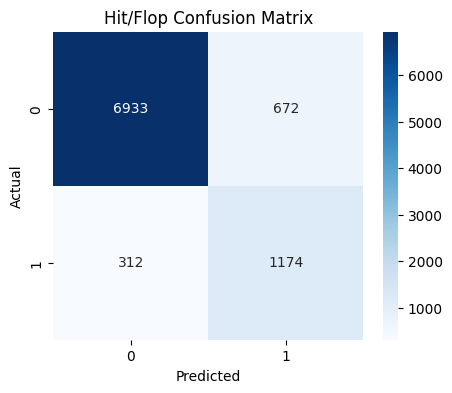

In [116]:
cm = confusion_matrix(y_cls_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hit/Flop Confusion Matrix")
plt.show()

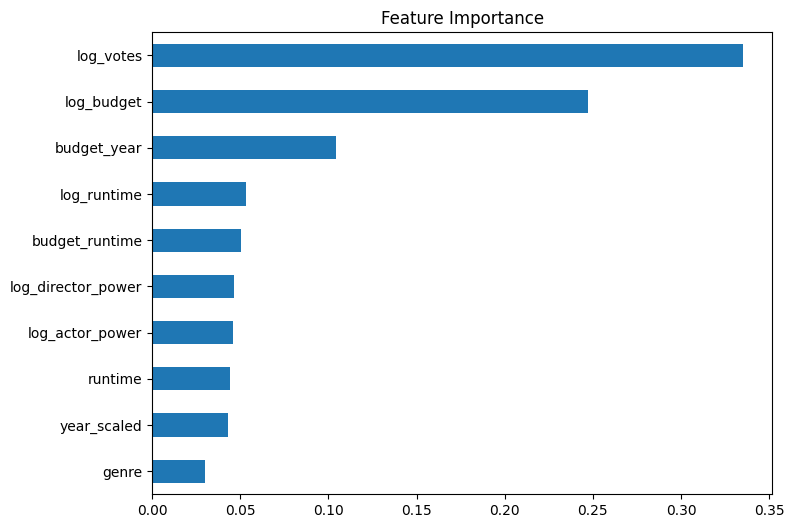

In [117]:
importance = pd.Series(xgb_reg.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [118]:
import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(xgb_reg, "../model/xgb_regressor.pkl")
joblib.dump(xgb_clf, "../model/xgb_classifier.pkl")

print("✅ Models saved in ../model/")

✅ Models saved in ../model/
